In [1]:
EXPERIMENT = "HomGrowth"

SAVE_FIGURES = False

# Imports

In [2]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

from tqdm import tqdm

import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".95"

In [3]:
if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    os.makedirs("figures", exist_ok=True)

# Load Results

In [5]:
def load_run_data_fig4(run_id):
    """Load training log, initial state, and trained model for a given run.

    Args:
        run_id: String identifier for the training run

    Returns:
        opt_hyper: Training hyperparams
        training_log: ReinforceTrainingLog object
        istate: Initial CellState
        initial_model: Initial model
        trained_model: Trained model
    """

    # key is not actually used in the code, but is required by the function signature
    # (we load weights from the savedmodels)
    key = jax.random.PRNGKey(0)

    # Load training hyperparams
    import json

    # load json
    with open(f"trained_models/train-{EXPERIMENT}-opt-hyperparams.json", "r") as f:
        opt_hyper = json.load(f)

    N_EPOCHS = opt_hyper["EPOCHS"]

    root_dir = f"trained_models/train-{EXPERIMENT}-{run_id}"

    # Load training metrics log
    from collections import namedtuple

    OptLog = namedtuple("OptimizationLog", ["loss", "val_loss"])
    training_log = OptLog([0.0] * (N_EPOCHS + 1), [0.0] * (N_EPOCHS + 1))

    with open(f"{root_dir}/results-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        training_log = eqx.tree_deserialise_leaves(fh, like=training_log)

    # Load initial state and model builder functions
    from fig4_istate_and_model import build_istate, build_model

    # Load initial state
    istate = build_istate(key)

    # Load model
    model = build_model(key, istate)

    # Load initial model
    with open(f"{root_dir}/init-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        initial_model = eqx.tree_deserialise_leaves(fh, like=model)

    # Load trained model
    with open(f"{root_dir}/trained-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        trained_model = eqx.tree_deserialise_leaves(fh, like=model)

    return opt_hyper, training_log, istate, initial_model, trained_model

# Single Run

In [6]:
RUN_ID = 1

In [7]:
opt_hyper, training_log, istate, initial_model, trained_model = load_run_data_fig4(
    RUN_ID
)

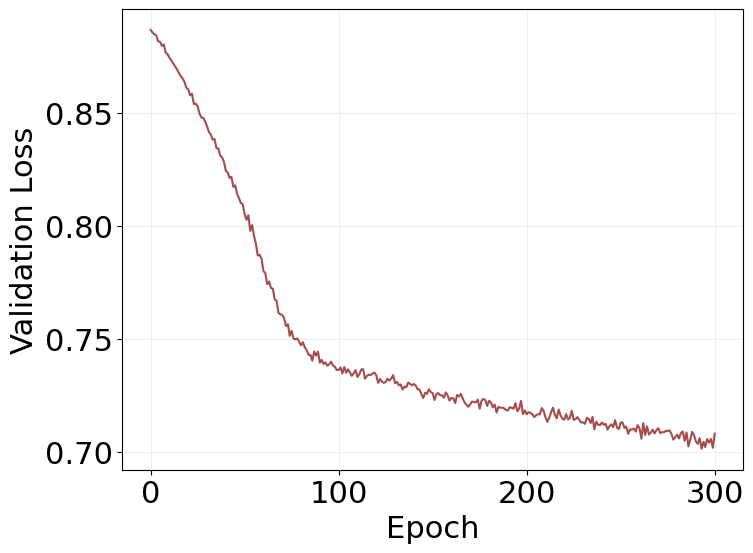

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(training_log.val_loss, color="maroon", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(alpha=0.2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/loss_curve_{EXPERIMENT}-{RUN_ID}.svg", dpi=300)

## Loss Distributions

In [9]:
def _final_cost_distribution(model, istate, subkeys, n_sim_steps):
    vsim = jax.vmap(jxm.simulate, (None, None, 0, None))
    fstate, _ = vsim(model, istate, subkeys, n_sim_steps)
    cost = np.std(fstate.division, axis=-2) / np.mean(fstate.division, axis=-2)
    return cost.flatten()

In [10]:
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))
subkeys = jax.random.split(key, 100)

icosts = _final_cost_distribution(initial_model, istate, subkeys, N_ADD)
ocosts = _final_cost_distribution(trained_model, istate, subkeys, N_ADD)

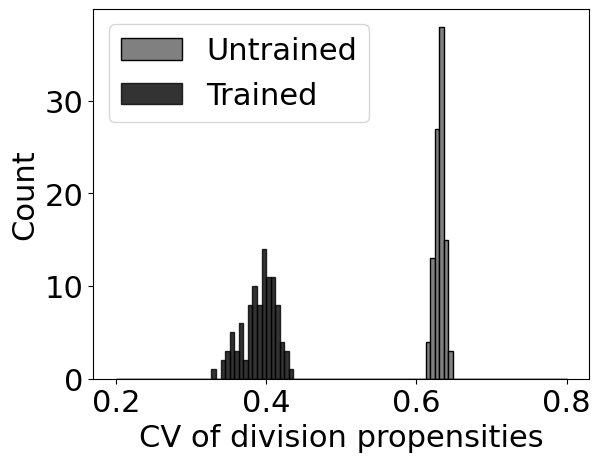

In [11]:
plt.hist(
    icosts,
    color="gray",
    edgecolor="black",
    label="Untrained",
    bins=np.linspace(0.2, 0.8, 100),
)

plt.hist(
    ocosts,
    color="black",
    edgecolor="black",
    alpha=0.8,
    label="Trained",
    bins=np.linspace(0.2, 0.8, 100),
)

plt.xlabel("CV of division propensities")
plt.ylabel("Count")

plt.legend()

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-finalcosts-dist.svg", bbox_inches="tight"
    )

## Initialized model

In [12]:
int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

100

In [13]:
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

key, subkey = jax.random.split(key)
fstate_i, _ = jxm.simulate(initial_model, istate, subkey, N_ADD)

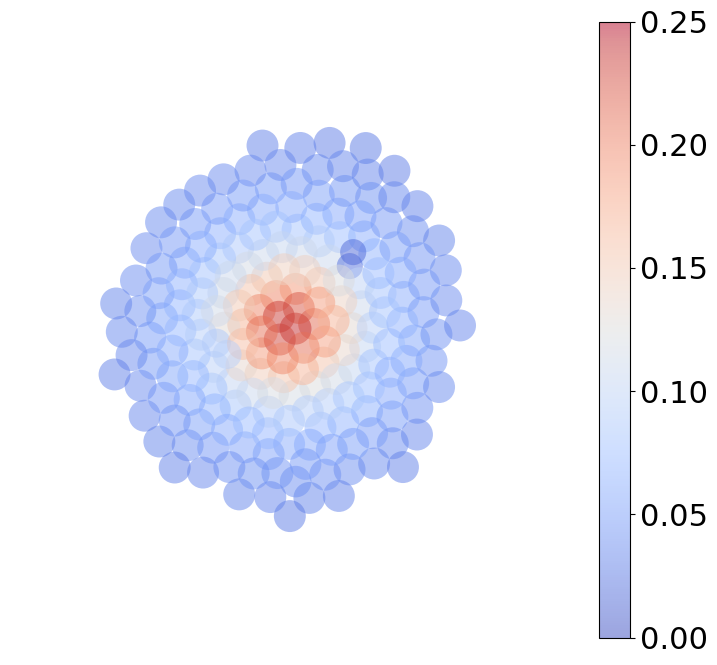

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax = jxm.visualization.draw_circles(
    fstate_i, fstate_i.division, ax=ax, min_val=0.0, max_val=0.25
)

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-untrained-fstate.svg", bbox_inches="tight"
    )

## Trained model

In [15]:
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

key, subkey = jax.random.split(key)
fstate_opt, _ = jxm.simulate(trained_model, istate, subkey, N_ADD)

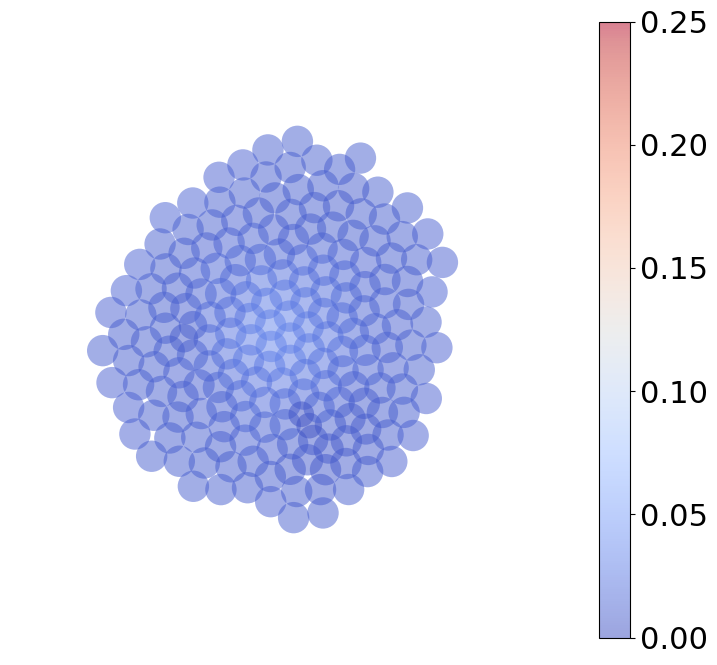

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax = jxm.visualization.draw_circles(
    fstate_opt, fstate_opt.division, ax=ax, min_val=0.0, max_val=0.25
)

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-trained-fstate.svg", bbox_inches="tight"
    )

## Network Visualization

In [17]:
# Make labels for network nodes
N_CHEM = istate.chemical.shape[-1]
N_HIDDEN = istate.hidden_state.shape[-1]

labels = []
labels += ["$c_{" + str(i + 1) + "}$" for i in range(N_CHEM)]
labels += ["$c_{" + str(i + 1) + j + "}$" for i in range(N_CHEM) for j in ["x", "y"]]
labels += ["stress"]
labels += ["$h_{" + str(i + 1) + "}$" for i in range(N_HIDDEN)]
labels += ["$s_{c_{" + str(i + 1) + "}}$" for i in range(N_CHEM)]
labels += ["div"]


inputs = [i for i in range(N_CHEM)]
inputs += [i for i in range(inputs[-1] + 1, inputs[-1] + 1 + 2 * N_CHEM + 1)]
hidden = [i for i in range(inputs[-1] + 1, inputs[-1] + 1 + N_HIDDEN)]
outputs = [i for i in range(hidden[-1] + 1, hidden[-1] + 1 + N_CHEM + 1)]
shells = [outputs, hidden, inputs]

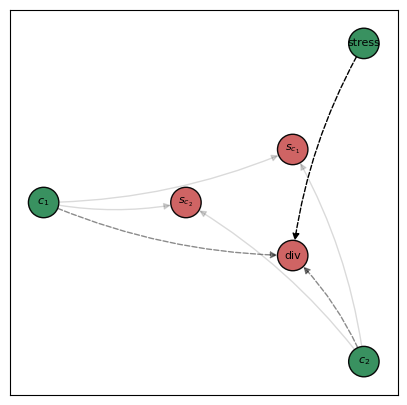

In [18]:
# In the simulation convention stress is the only negative quantity
# So a positive stress-division interaction means that stress actually inhibits division
# We flip the sign of the stress-division interaction to render more clearly the inhibitory effect of stress
W = trained_model[-1].interaction_matrix
W = W.at[6, -1].set(-W[6, -1])

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax = jxm.visualization.OLD_draw_network(
    W.T,
    eps=0.01,
    labels=labels,
    shells=shells,
    ax=ax,
)

if SAVE_FIGURES:
    plt.savefig(f"figures/{EXPERIMENT}-{RUN_ID}-network.svg", bbox_inches="tight")

# Alternative Division Fields

## Reload models w/ different field configs

In [19]:
from fig4_istate_and_model import build_model

fields = ["exp", "two_peaks", "off_center"]

In [20]:
# Reload model with different field configs

f_models_trained = []
f_models_initial = []

for field in fields:
    f_model_i = build_model(key, istate, field_type=field)
    with open(
        f"trained_models/train-{EXPERIMENT}-{RUN_ID}/trained-{EXPERIMENT}-{RUN_ID}.eqx",
        "rb",
    ) as fh:
        f_model_o = eqx.tree_deserialise_leaves(fh, f_model_i)
    f_models_initial.append(f_model_i)
    f_models_trained.append(f_model_o)

## Division CVs on other fields

In [21]:
subkeys = np.asarray(jax.random.split(key, 100))

icosts_f = []
ocosts_f = []

for f_model_i, f_model_o in tqdm(
    zip([initial_model] + f_models_initial, [trained_model] + f_models_trained),
    total=4,
):

    icosts = _final_cost_distribution(f_model_i, istate, subkeys, n_sim_steps=N_ADD)
    ocosts = _final_cost_distribution(f_model_o, istate, subkeys, n_sim_steps=N_ADD)
    icosts_f.append(icosts)
    ocosts_f.append(ocosts)

100%|█████████████████████████████████████████████| 4/4 [01:29<00:00, 22.46s/it]


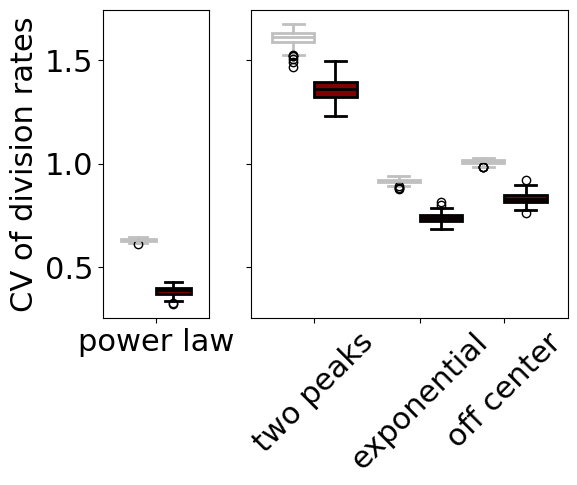

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4), sharey=True, width_ratios=[1, 3])

key, subkey = jax.random.split(key)

boxplots = ax[1].boxplot(
    [icosts_f[1], ocosts_f[1], icosts_f[2], ocosts_f[2], icosts_f[3], ocosts_f[3]],
    positions=[1.0, 1.5, 2.25, 2.75, 3.25, 3.75],
    widths=0.5,
    patch_artist=True,
)
boxplot_pl = ax[0].boxplot(
    [icosts_f[0], ocosts_f[0]], positions=[1, 1.5], widths=0.5, patch_artist=True
)

ax[0].set_xticks(
    ticks=[
        1.25,
    ],
    labels=["power law"],
)
ax[1].set_xticks(
    ticks=[1.25, 2.5, 3.5],
    labels=["two peaks", "exponential", "off center"],
    rotation=45,
)

box_colors = ["white", "maroon"]
line_colors = ["silver", "black"]
for i, box in enumerate(boxplot_pl["boxes"]):
    box.set_facecolor(box_colors[i])
    box.set_edgecolor(line_colors[i])
    box.set_linewidth(2)
    boxplot_pl["medians"][i].set(color=line_colors[i], linewidth=2)
    boxplot_pl["whiskers"][i * 2].set(color=line_colors[i], linewidth=2)
    boxplot_pl["whiskers"][i * 2 + 1].set(color=line_colors[i], linewidth=2)
    boxplot_pl["caps"][i * 2].set(color=line_colors[i], linewidth=2)
    boxplot_pl["caps"][i * 2 + 1].set(color=line_colors[i], linewidth=2)

box_colors = ["white", "maroon", "white", "maroon", "white", "maroon"]
line_colors = ["silver", "black", "silver", "black", "silver", "black"]
for i, box in enumerate(boxplots["boxes"]):
    box.set_facecolor(box_colors[i])
    box.set_edgecolor(line_colors[i])
    box.set_linewidth(2)
    boxplots["medians"][i].set(color=line_colors[i], linewidth=2)
    boxplots["whiskers"][i * 2].set(color=line_colors[i], linewidth=2)
    boxplots["whiskers"][i * 2 + 1].set(color=line_colors[i], linewidth=2)
    boxplots["caps"][i * 2].set(color=line_colors[i], linewidth=2)
    boxplots["caps"][i * 2 + 1].set(color=line_colors[i], linewidth=2)
ax[0].set_ylabel("CV of division rates")

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-trained-otherfields.svg", bbox_inches="tight"
    )

## Radial division profiles

In [23]:
def model_patch(model, istate, subkey):
    n_add = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))
    fstate, _ = jxm.simulate(model, istate, subkey, n_steps=n_add)
    sel = (fstate.position[:, 1] > -1) & (fstate.position[:, 1] < 1)
    x = fstate.position[sel, 0]
    y = fstate.division[sel] / fstate.field[sel]
    y = y / np.max(y)
    return x, y.flatten()


key, subkey = jax.random.split(key)

xo_f, yo_f = [], []

for f_model_o in [trained_model] + f_models_trained:
    xo, yo = model_patch(f_model_o, istate, subkey)
    xo_f.append(xo)
    yo_f.append(yo)

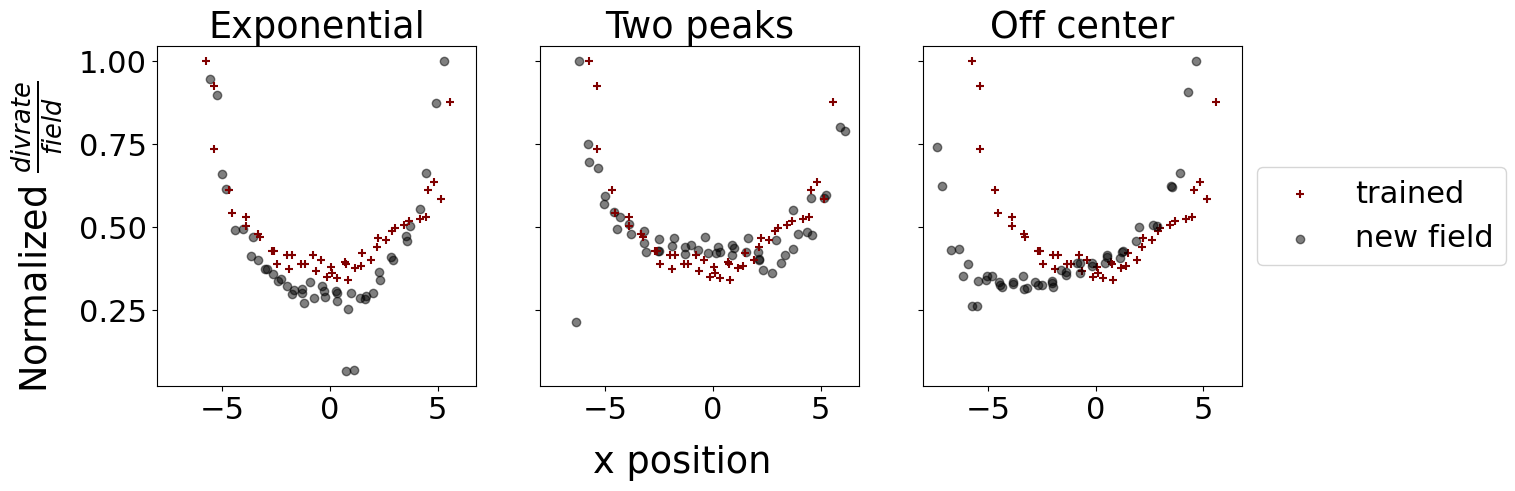

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)
ax[0].scatter(xo_f[1], yo_f[1], color="black", alpha=0.5, label="new field")
ax[0].scatter(xo_f[0], yo_f[0], color="maroon", marker="+", label="trained")
ax[0].set_title("Exponential")

ax[1].scatter(xo_f[2], yo_f[2], color="black", label="two peak", alpha=0.5)
ax[1].scatter(xo_f[0], yo_f[0], color="maroon", marker="+", label="trained")
ax[1].set_title("Two peaks")

ax[2].scatter(xo_f[0], yo_f[0], color="maroon", marker="+", label="trained")
ax[2].scatter(xo_f[3], yo_f[3], color="black", label="new field", alpha=0.5)
ax[2].set_title("Off center")
ax[2].legend(loc="center left", bbox_to_anchor=(1, 0.5))

fig.supxlabel("x position")
fig.supylabel(r"Normalized $\frac{divrate}{field}$")

fig.subplots_adjust(bottom=0.2)

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-trained-otherfields-scatter.svg",
        bbox_inches="tight",
    )

# Model Ablations

In [25]:
# Ablated models
ablate_stress = eqx.tree_at(
    lambda m: m[-1].interaction_matrix,
    trained_model,
    trained_model[-1].interaction_matrix.at[6, :].set(0.0),
)
ablate_chem = eqx.tree_at(
    lambda m: m[-1].interaction_matrix,
    trained_model,
    trained_model[-1].interaction_matrix.at[:2, :].set(0.0).at[:, -3:-1].set(0.0),
)
ablate_chem_grad = eqx.tree_at(
    lambda m: m[-1].interaction_matrix,
    trained_model,
    trained_model[-1].interaction_matrix.at[2:5, :].set(0.0),
)

In [26]:
subkeys = np.asarray(jax.random.split(key, 200))

ablated_costs = []
for ablated_model in [ablate_stress, ablate_chem, ablate_chem_grad, trained_model]:
    costs = _final_cost_distribution(ablated_model, istate, subkeys, n_sim_steps=N_ADD)
    ablated_costs.append(costs)

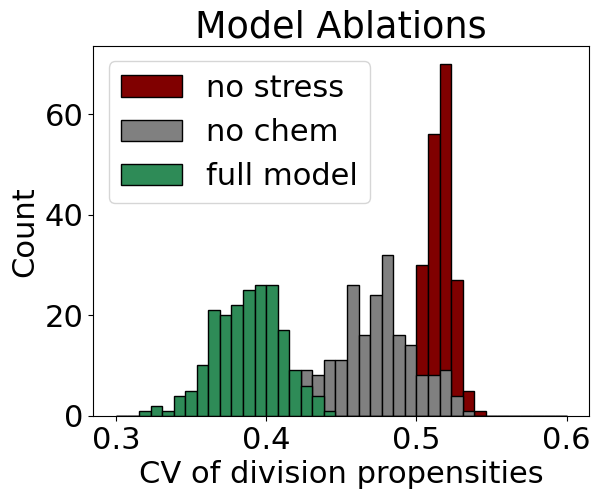

In [27]:
plt.hist(
    ablated_costs[0],
    bins=np.linspace(0.3, 0.6, 40),
    edgecolor="black",
    label="no stress",
    color="maroon",
)
plt.hist(
    ablated_costs[1],
    bins=np.linspace(0.3, 0.6, 40),
    edgecolor="black",
    label="no chem",
    color="gray",
)
plt.hist(
    ablated_costs[3],
    bins=np.linspace(0.3, 0.6, 40),
    edgecolor="black",
    label="full model",
    color="seagreen",
)
plt.legend()
plt.title("Model Ablations")
plt.xlabel("CV of division propensities")
plt.ylabel("Count")

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-ablations-dist.svg", bbox_inches="tight"
    )